# ITR 1 — Finding Similar Items in Rater Behavior (LSH for Independence)

How can finding similar items in rater behavior illuminate structural independence across raters?  
This ITR builds a scalable pipeline that analyzes the full `ratings.parquet` dataset to identify similar long-run patterns between raters and uses those similarities to estimate structural independence in Community Notes.

Here, structural independence is defined in terms of behavioral similarity. Each rater is represented by how often they mark notes as helpful across eight consolidated meta-topics. When very few rater pairs exhibit similar patterns across these domains, the system looks independent: raters are making distinct judgments. When many pairs look similar, that suggests structural dependence, such as shared heuristics, correlated participation, or coordinated behavior.

Because the dataset contains millions of raters, directly comparing all possible pairs is not feasible. Instead, I use Locality-Sensitive Hashing (LSH) on an RCC bigmem node to approximate similarity at scale. LSH groups together raters whose behavioral vectors fall within a chosen distance threshold, allowing the analysis to scan for “near neighbors” without computing every pairwise distance.

**This notebook proceeds as follows:**

1. Representation of rater behavior  
2. Similarity as a proxy for independence  
3. Locality-Sensitive Hashing (LSH)  
4. Scalable implementation on an RCC bigmem node  


## Literature Review

Locality-Sensitive Hashing (LSH) is widely used in recent scholarly work as a scalable way to detect similarity in large, high-dimensional datasets. Across different research areas, LSH plays the same role: it makes similarity search feasible when the number of comparisons would otherwise be too large to compute exactly. The three papers below illustrate how LSH is currently being applied and how these uses relate to my independence diagnostic.

Bestagini et al. (2024) apply LSH to large-scale multimedia forensics, using it to detect near-duplicate or manipulated images in massive collections. Their results show that LSH can reliably identify similar items while reducing computation by orders of magnitude. This directly supports using LSH in Community Notes, where millions of rater vectors make full pairwise comparison impossible.

Sawant et al. (2023) use LSH in recommender-system modeling to group users with similar interaction histories. Instead of comparing every user to every other user, LSH creates buckets of likely matches that can be examined more closely. This is closely related to my method: instead of user–item interactions, I analyze rater–topic helpfulness patterns, and use LSH to find whether raters fall into overlapping behavioral “buckets.”

Adhikary et al. (2022) use LSH for anomaly detection in IoT networks, hashing behavioral signatures and identifying flows that deviate from typical patterns. Their use of LSH as a structural diagnostic parallels my goal: treating similarity densities as evidence for whether behavior is dispersed or clustered.

Together, these applications show that LSH is a well-established method for identifying behavioral similarity at scale. This supports its use in constructing a structural independence metric for Community Notes.


## Method Overview

### 1. How rater behavior is represented
Each rater is represented by an eight-dimensional vector: their average helpfulness rate in each meta-topic. Collapsing the fine-grained topic labels into eight meta-topics produces stable, interpretable features without changing the number of raters.

### 2. Why similarity is used as a proxy for independence
Because independence cannot be observed directly, I use similarity in long-run behavior as an indirect indicator.  
A low similarity rate implies that most raters maintain distinct behavioral patterns.  
A high similarity rate implies that many raters follow the same pattern, indicating dependence.

This diagnostic does not aim to identify specific sources of dependence. It only evaluates whether long-run behavioral patterns remain dispersed.

### 3. Why Locality-Sensitive Hashing (LSH)
The rater × meta-topic matrix is too large for exact pairwise comparison. LSH provides a scalable approximation by hashing similar vectors into the same bucket. From these buckets, I estimate the rate at which rater pairs fall within a chosen similarity threshold.


## Implementation: scalable sampling and LSH on bigmem

The main function, run_sample_density, does the following:

1. Takes a random subsample of raters.
2. Turns their eight meta-topic scores into normalized feature vectors.
3. Uses Locality-Sensitive Hashing (LSH) to find rater pairs that are closer than a
   chosen distance threshold.
4. Records the share of similar pairs among all possible pairs in the sample as the structural similarity rate.

I work with samples rather than the full population because the full rater × meta-topic matrix is too large for reliable all-pairs similarity search.

Because of memory limits and occasional failures on RCC, I structured the code so the
same logic can be safely restarted and run multiple times. I then repeat the sampling
over several fractions (3–10%) and random seeds to check how stable the similarity rate
is. The resulting summary table is saved and later used for plots and interpretation in
the write-up.


## Independence Diagnostic Pipeline

This section summarizes the main steps of the independence diagnostic.

### Step 1: Build the rater × meta-topic matrix

Using the joined ratings and notes data, I aggregate each rater’s behavior into eight meta-topics.  
This creates a rater × meta-topic matrix in which each row is a behavioral profile:

| Rater   | Politics | Policy | Scams | Health | Culture | Norms | Conflicts | ... |
|---------|----------|--------|-------|--------|---------|-------|-----------|-----|
| R12345  | 0.73     | 0.21   | 0.04  | 0.15   | 0.42    | 0.56  | 0.30      | ... |
| R98765  | 0.12     | 0.48   | 0.61  | 0.09   | 0.18    | 0.22  | 0.11      | ... |

Each cell expresses the **share of notes in that domain that the rater marked as helpful**, summarizing their long-run evaluative stance across informational domains.

---

### Step 2: Draw random subsamples of raters

I then draw several random subsamples of raters at different fractions of the full population (3%, 5%, 8%, 10%), each with multiple seeds:

| Sample ID | Fraction of raters | Seed | Number of raters |
|-----------|--------------------|------|------------------|
| S1        | 0.03               | 42   | *N₁*             |
| S2        | 0.05               | 7    | *N₂*             |
| S3        | 0.08               | 100  | *N₃*             |
| ...       | ...                | ...  | ...              |

These subsamples make it possible to estimate similarity rates without loading all raters into a single, fragile job.

---

### Step 3: Turn rows into normalized feature vectors

For each sample, I convert the meta-topic columns into feature vectors and normalize them:

| Rater   | Raw vector (8 dims)                 | Normalized vector (‖v‖₂ = 1)      |
|---------|-------------------------------------|-----------------------------------|
| R12345  | (0.73, 0.21, 0.04, ..., 0.30)       | (v₁, v₂, v₃, ..., v₈)            |
| R98765  | (0.12, 0.48, 0.61, ..., 0.11)       | (w₁, w₂, w₃, ..., w₈)            |

This puts all raters into the same geometric space, where distances correspond to differences in long-run behavior across meta-topics.

---

### Step 4: Hash raters and search for near neighbors (LSH)

I then apply Locality-Sensitive Hashing (LSH) to the normalized vectors:

| Hash bucket | Raters assigned               |
|-------------|-------------------------------|
| B₁          | R12345, R54789, R77110, ...   |
| B₂          | R98765, R00641, R22031, ...   |
| ...         | ...                           |

Raters that fall into the same bucket are treated as **candidates** for being similar.  
Within these candidate sets, the LSH routine computes approximate distances and keeps only rater pairs whose distance is below the threshold τ.

---

### Step 5: Compute the structural similarity rate

For each sample, I count how many unique rater pairs fall under the similarity threshold:

\[
\text{Structural similarity rate} = \frac{\text{Number of similar rater pairs}}{\text{Total possible pairs in the sample}}.
\]

Example structure:

| Sample ID | τ (threshold) | Similar pairs | Total pairs | Similarity rate |
|-----------|---------------|---------------|-------------|-----------------|
| S1        | 0.35          | *K₁*          | *M₁*        | *K₁* / *M₁*      |
| S2        | 0.35          | *K₂*          | *M₂*        | *K₂* / *M₂*      |
| ...       | ...           | ...           | ...         | ...             |

This rate is the core empirical quantity I interpret as evidence about independence.

---

### Step 6: Check stability across samples and thresholds

Finally, I vary both the **sample fraction** and the **distance threshold τ** and compare the resulting similarity rates across runs:

| Fraction | τ     | Mean similarity rate | SD across runs |
|----------|-------|----------------------|----------------|
| 0.03     | 0.35  | ~0.034               | small          |
| 0.05     | 0.35  | ~0.034               | small          |
| 0.10     | 0.35  | ~0.033               | small          |
| 0.05     | 0.30–0.38 | increasing smoothly | small      |

The absence of large shifts across fractions and thresholds is what I treat as evidence that the independence signal is stable.


In [ ]:
# ============================================================
# COMMUNITY NOTES DEPENDENCE MODELING — SAFE SAMPLING VERSION
# ============================================================

from pyspark.sql import SparkSession, functions as F
from pyspark.ml.feature import VectorAssembler, Normalizer, BucketedRandomProjectionLSH
import os, time, json, re, subprocess, shutil, random

# ------------------------------------------------------------
# 0) PATHS & CONFIG
# ------------------------------------------------------------
PROJECT_ROOT = "/project/macs40123/jonathanmonroe/macs-40123-JonathanPMonroe"
DATA_DIR     = f"{PROJECT_ROOT}/data"
OUTPUT_DIR   = f"{DATA_DIR}/interim/outputs"
RATINGS_PATH = f"{DATA_DIR}/interim/ratings_parquet/ratings.parquet"
NOTES_PATH   = f"{OUTPUT_DIR}/notes_topics_labeled_with_labels.parquet"
MAPPING_PATH = f"{OUTPUT_DIR}/meta_topic_mapping.json"
TMP_ROOT     = "/scratch/midway3/jonathanmonroe/spark_tmp" 

os.makedirs(TMP_ROOT, exist_ok=True)
print(f"Using scratch dir root: {TMP_ROOT}")

SCRATCH_LIMIT_GB = 200.0
SHUFFLE_PARTS = 50

# ------------------------------------------------------------
# 1) DISK GUARDS
# ------------------------------------------------------------
def du_gb(path):
    """Disk usage in GB."""
    try:
        out = subprocess.check_output(["du", "-s", path], text=True).strip().split()[0]
        return float(out) / 1_000_000.0
    except Exception:
        return 0.0

def guard_scratch(limit_gb=SCRATCH_LIMIT_GB, where="Check"):
    used = du_gb(TMP_ROOT)
    print(f"[{where}] Scratch usage = {used:.1f} GB (limit {limit_gb:.0f} GB)")
    if used > limit_gb:
        raise RuntimeError(f"Scratch usage {used:.1f} GB > limit {limit_gb:.0f} GB — aborting.")

# ------------------------------------------------------------
# 2) SPARK SESSION (BIGMEM SAFE CONFIG)
# ------------------------------------------------------------
try:
    if 'spark' in locals() and spark:
        spark.stop()
    print("Stopped existing Spark session.")
except Exception:
    pass

spark = (
    SparkSession.builder
    .appName("dependence_modeling_sampling_safe")
    .config("spark.driver.memory", "48g")
    .config("spark.executor.memory", "60g")
    .config("spark.sql.shuffle.partitions", str(SHUFFLE_PARTS))
    .config("spark.local.dir", TMP_ROOT)
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer")
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")
    .config("spark.memory.fraction", "0.70")
    .config("spark.memory.storageFraction", "0.30")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")
print("Spark session initialized.\n")

GLOBAL_SPARK_LOCAL_DIR = spark.conf.get("spark.local.dir")

# ------------------------------------------------------------
# 3) LOAD AND BUILD RATER × META-TOPIC MATRIX
# ------------------------------------------------------------
print("Loading ratings and notes...")

ratings = (
    spark.read.parquet(RATINGS_PATH)
    .select("noteId", "raterParticipantId", "helpfulnessLevel")
    .dropna(subset=["noteId", "raterParticipantId"])
    .dropDuplicates(["noteId", "raterParticipantId"])
    .withColumn("any_helpful", F.when(F.col("helpfulnessLevel").isin("HELPFUL", "SOMEWHAT_HELPFUL"), 1).otherwise(0))
)

with open(MAPPING_PATH, "r") as f:
    meta_labels = json.load(f)
mapping_expr = F.create_map(*[x for kv in meta_labels.items() for x in (F.lit(kv[0]), F.lit(kv[1]))])

notes = (
    spark.read.parquet(NOTES_PATH)
    .select("noteId", "topic_label")
    .withColumn("meta_label", mapping_expr[F.col("topic_label")])
    .dropna(subset=["meta_label"])
    .dropDuplicates(["noteId", "meta_label"])
)

joined = ratings.join(notes, on="noteId", how="inner").select("raterParticipantId", "meta_label", "any_helpful")

rater_topic = (
    joined.groupBy("raterParticipantId", "meta_label")
    .agg(F.mean("any_helpful").alias("mean_helpfulness"), F.count("*").alias("n_ratings"))
    .filter(F.col("n_ratings") >= 5)
)

matrix = (
    rater_topic.groupBy("raterParticipantId")
    .pivot("meta_label")
    .agg(F.first("mean_helpfulness"))
    .fillna(0.0)
)

# Sanitize column names
for old in matrix.columns:
    if old != "raterParticipantId":
        safe = re.sub(r"[^a-zA-Z0-9_]", "_", old)
        matrix = matrix.withColumnRenamed(old, safe)

matrix.cache()
topic_cols = [c for c in matrix.columns if c != "raterParticipantId"]
n_raters = matrix.count()
print(f"Matrix loaded with {len(topic_cols)} meta-topics and {n_raters:,} raters.\n")

guard_scratch(where="Post-Matrix Load")

# ------------------------------------------------------------
# 4) SAMPLING FUNCTION — SAFE SUBDIR PER RUN
# ------------------------------------------------------------
def run_sample_density(spark_session, matrix_df, topic_cols, frac, seed,
                       threshold=0.35, bucket_length=0.02,
                       num_hash_tables=8, shuffle_parts=50):
    """Run dependence-density estimate for a sampled subset safely."""
    t0 = time.time()
    
    run_tag = f"run_{int(time.time() * 1000)}_{seed}"
    local_tmp = f"{TMP_ROOT}/{run_tag}"
    os.makedirs(local_tmp, exist_ok=True)

    spark_session.conf.set("spark.local.dir", local_tmp)
    print(f"\n=== Running sample: frac={frac:.2%}, seed={seed}, tmp={local_tmp} ===")

    sample_df = matrix_df.sample(False, frac, seed=seed)
    n_sample = sample_df.count()
    
    sample_df = sample_df.repartition(shuffle_parts, "raterParticipantId").cache()
    _ = sample_df.count()
    print(f"Sampled {n_sample:,} raters.")

    if n_sample < 10:
        return {"frac": frac, "seed": seed, "n_raters": n_sample,
                "pairs": 0, "near_pairs": 0, "density": 0.0, "secs": time.time() - t0}

    assembler = VectorAssembler(inputCols=topic_cols, outputCol="features_raw")
    normalizer = Normalizer(inputCol="features_raw", outputCol="features", p=2.0)
    df_norm = normalizer.transform(assembler.transform(sample_df)).select("raterParticipantId", "features").cache()
    _ = df_norm.count()

    lsh = BucketedRandomProjectionLSH(
        inputCol="features",
        outputCol="hashes",
        bucketLength=bucket_length,
        numHashTables=num_hash_tables,
    ).fit(df_norm)

    df_h = lsh.transform(df_norm).select("raterParticipantId", "features", "hashes").cache()
    _ = df_h.count()

    A = df_h.repartition(shuffle_parts, "hashes").withColumnRenamed("raterParticipantId", "raterA").alias("A")
    B = df_h.repartition(shuffle_parts, "hashes").withColumnRenamed("raterParticipantId", "raterB").alias("B")

    pairs = (
        lsh.approxSimilarityJoin(A, B, threshold, distCol="distance")
        .filter(F.col("datasetA.raterA") < F.col("datasetB.raterB"))
        .select(
            F.col("datasetA.raterA").alias("raterA"),
            F.col("datasetB.raterB").alias("raterB"),
            "distance",
        )
        .repartition(shuffle_parts)
    )
    
    near_pairs = pairs.count()
    possible_pairs = n_sample * (n_sample - 1) / 2
    density = near_pairs / possible_pairs if possible_pairs else 0.0

    df_h.unpersist()
    df_norm.unpersist()
    sample_df.unpersist()

    try:
        shutil.rmtree(local_tmp, ignore_errors=True)
        print(f"Cleaned scratch dir: {local_tmp}")
    except Exception as e:
        print(f"Warning: could not clean {local_tmp}: {e}")

    return {
        "frac": frac,
        "seed": seed,
        "n_raters": n_sample,
        "pairs": possible_pairs,
        "near_pairs": near_pairs,
        "density": float(density),
        "secs": time.time() - t0,
    }

# ------------------------------------------------------------
# 5) SAMPLING GRID EXECUTION
# ------------------------------------------------------------
FRACTIONS = [0.03, 0.05, 0.08, 0.10]
SEEDS = [42, 7, 100]
results = []

for f in FRACTIONS:
    for s in SEEDS:
        res = run_sample_density(spark, matrix, topic_cols, f, s, shuffle_parts=SHUFFLE_PARTS)
        results.append(res)
        
        spark.catalog.clearCache()
        spark.conf.set("spark.local.dir", GLOBAL_SPARK_LOCAL_DIR)
        guard_scratch(where=f"Post-Run frac={f:.2%}, seed={s}")

# ------------------------------------------------------------
# 6) SAVE RESULTS & FINAL CLEANUP
# ------------------------------------------------------------
res_df = spark.createDataFrame(results)
out_path = f"{OUTPUT_DIR}/dependence_density_sampling_grid.parquet"
res_df.write.mode("overwrite").parquet(out_path)
res_df.orderBy("frac", "seed").show(truncate=False)

print(f"\nSaved sampling summary → {out_path}")

matrix.unpersist()
spark.stop()
print("Spark session closed cleanly.")


Using scratch dir root: /scratch/midway3/jonathanmonroe/spark_tmp
Stopped existing Spark session.


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/10/23 02:46:57 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/10/23 02:46:57 WARN SparkConf: Note that spark.local.dir will be overridden by the value set by the cluster manager (via SPARK_LOCAL_DIRS in mesos/standalone/kubernetes and LOCAL_DIRS in YARN).


Spark session initialized.

Loading ratings and notes...


25/10/23 02:47:09 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/10/23 02:47:09 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/10/23 02:47:09 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/10/23 02:47:10 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.


Matrix loaded with 8 meta-topics and 606,106 raters.

[Post-Matrix Load] Scratch usage = 25.5 GB (limit 200 GB)

=== Running sample: frac=3.00%, seed=42, tmp=/scratch/midway3/jonathanmonroe/spark_tmp/run_1761205885018_42 ===
Sampled 18,151 raters.


...

25/10/23 03:41:03 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/10/23 03:41:03 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/10/23 03:41:03 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/10/23 03:41:03 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.


Sampled 60,856 raters.


Cleaned scratch dir: /scratch/midway3/jonathanmonroe/spark_tmp/run_1761208858649_42
[Post-Run frac=10.00%, seed=42] Scratch usage = 54.1 GB (limit 200 GB)

=== Running sample: frac=10.00%, seed=7, tmp=/scratch/midway3/jonathanmonroe/spark_tmp/run_1761209470020_7 ===


25/10/23 03:51:14 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/10/23 03:51:14 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/10/23 03:51:14 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/10/23 03:51:14 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.


Sampled 60,377 raters.


In [ ]:
# ============================================================
# COMMUNITY NOTES — FULL RESTART + RESUME SAFE SAMPLING
# ============================================================

import os, re, time, json, shutil, subprocess
from pyspark.sql import SparkSession, functions as F
from pyspark.ml.feature import VectorAssembler, Normalizer, BucketedRandomProjectionLSH

# ------------------------------
# 1. PATHS & ENVIRONMENT SETUP
# ------------------------------
PROJECT_ROOT = "/project/macs40123/jonathanmonroe/macs-40123-JonathanPMonroe"
DATA_DIR = f"{PROJECT_ROOT}/data"
OUTPUT_DIR = f"{DATA_DIR}/interim/outputs"
RATINGS_PATH = f"{DATA_DIR}/interim/ratings_parquet/ratings.parquet"
NOTES_PATH   = f"{OUTPUT_DIR}/notes_topics_labeled_with_labels.parquet"
MAPPING_PATH = f"{OUTPUT_DIR}/meta_topic_mapping.json"
RES_PATH     = f"{OUTPUT_DIR}/dependence_density_sampling_grid.parquet"
TMP_ROOT     = "/scratch/midway3/jonathanmonroe/spark_tmp"

# Clean & recreate scratch directory
if os.path.exists(TMP_ROOT):
    shutil.rmtree(TMP_ROOT, ignore_errors=True)
os.makedirs(TMP_ROOT, exist_ok=True)
print(f"Scratch directory ready: {TMP_ROOT}")

# ------------------------------
# 2. SAFE SPARK INITIALIZATION
# ------------------------------
try:
    spark.stop()
except Exception:
    pass

spark = (
    SparkSession.builder
    .appName("dependence_modeling_resume_safe")
    .config("spark.driver.memory", "48g")
    .config("spark.executor.memory", "60g")
    .config("spark.sql.shuffle.partitions", "50")
    .config("spark.local.dir", TMP_ROOT)
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer")
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")
print("Spark initialized.\n")

# ------------------------------
# 3. UTILITY FUNCTIONS
# ------------------------------
def du_gb(path):
    """Disk usage in GB."""
    try:
        out = subprocess.check_output(["du", "-s", path], text=True).strip().split()[0]
        return float(out) / 1_000_000.0
    except Exception:
        return 0.0

def guard_scratch(where="Check", limit_gb=200.0):
    used = du_gb(TMP_ROOT)
    print(f"[{where}] Scratch usage = {used:.1f} GB (limit {limit_gb:.0f} GB)")
    if used > limit_gb:
        raise RuntimeError(f"Scratch usage {used:.1f} GB > limit {limit_gb:.0f} GB — aborting.")

# ------------------------------
# 4. LOAD MATRIX IF NOT IN MEMORY
# ------------------------------
try:
    matrix
    topic_cols
    print("Using cached matrix from previous context.")
except NameError:
    print("Reloading matrix from source parquet...")

    ratings = (
        spark.read.parquet(RATINGS_PATH)
        .select("noteId", "raterParticipantId", "helpfulnessLevel")
        .dropna(subset=["noteId", "raterParticipantId"])
        .dropDuplicates(["noteId", "raterParticipantId"])
        .withColumn(
            "any_helpful",
            F.when(F.col("helpfulnessLevel").isin("HELPFUL", "SOMEWHAT_HELPFUL"), 1).otherwise(0)
        )
    )

    with open(MAPPING_PATH, "r") as f:
        meta_labels = json.load(f)
    mapping_expr = F.create_map(*[x for kv in meta_labels.items() for x in (F.lit(kv[0]), F.lit(kv[1]))])

    notes = (
        spark.read.parquet(NOTES_PATH)
        .select("noteId", "topic_label")
        .withColumn("meta_label", mapping_expr[F.col("topic_label")])
        .dropna(subset=["meta_label"])
        .dropDuplicates(["noteId", "meta_label"])
    )

    joined = ratings.join(notes, on="noteId", how="inner").select("raterParticipantId", "meta_label", "any_helpful")

    rater_topic = (
        joined.groupBy("raterParticipantId", "meta_label")
        .agg(F.mean("any_helpful").alias("mean_helpfulness"), F.count("*").alias("n_ratings"))
        .filter(F.col("n_ratings") >= 5)
    )

    matrix = (
        rater_topic.groupBy("raterParticipantId")
        .pivot("meta_label")
        .agg(F.first("mean_helpfulness"))
        .fillna(0.0)
    )

    for old in matrix.columns:
        if old != "raterParticipantId":
            safe = re.sub(r"[^a-zA-Z0-9_]", "_", old)
            matrix = matrix.withColumnRenamed(old, safe)

    matrix.cache()
    topic_cols = [c for c in matrix.columns if c != "raterParticipantId"]
    n_raters = matrix.count()
    print(f"Matrix reloaded with {len(topic_cols)} topics and {n_raters:,} raters.\n")

# ------------------------------
# 5. DEFINE LSH SAMPLING FUNCTION
# ------------------------------
def run_sample_density(spark_session, matrix_df, topic_cols, frac, seed,
                       threshold=0.35, bucket_length=0.02,
                       num_hash_tables=8, shuffle_parts=50):
    t0 = time.time()
    run_tag = f"run_{int(time.time() * 1000)}_{seed}"
    local_tmp = f"{TMP_ROOT}/{run_tag}"
    os.makedirs(local_tmp, exist_ok=True)
    spark_session.conf.set("spark.local.dir", local_tmp)

    print(f"\n=== Running sample: frac={frac:.2%}, seed={seed}, tmp={local_tmp} ===")

    sample_df = matrix_df.sample(False, frac, seed=seed)
    n_sample = sample_df.count()
    sample_df = sample_df.repartition(shuffle_parts, "raterParticipantId").cache()
    _ = sample_df.count()
    print(f"Sampled {n_sample:,} raters.")

    if n_sample < 10:
        shutil.rmtree(local_tmp, ignore_errors=True)
        return {"frac": frac, "seed": seed, "n_raters": n_sample,
                "pairs": 0, "near_pairs": 0, "density": 0.0, "secs": time.time() - t0}

    assembler = VectorAssembler(inputCols=topic_cols, outputCol="features_raw")
    normalizer = Normalizer(inputCol="features_raw", outputCol="features", p=2.0)
    df_norm = normalizer.transform(assembler.transform(sample_df)).select("raterParticipantId", "features").cache()
    _ = df_norm.count()

    lsh = BucketedRandomProjectionLSH(
        inputCol="features", outputCol="hashes",
        bucketLength=bucket_length, numHashTables=num_hash_tables
    ).fit(df_norm)

    df_h = lsh.transform(df_norm).select("raterParticipantId", "features", "hashes").cache()
    _ = df_h.count()

    A = df_h.repartition(shuffle_parts, "hashes").withColumnRenamed("raterParticipantId", "raterA").alias("A")
    B = df_h.repartition(shuffle_parts, "hashes").withColumnRenamed("raterParticipantId", "raterB").alias("B")

    pairs = (
        lsh.approxSimilarityJoin(A, B, threshold, distCol="distance")
        .filter(F.col("datasetA.raterA") < F.col("datasetB.raterB"))
        .select(F.col("datasetA.raterA").alias("raterA"),
                F.col("datasetB.raterB").alias("raterB"), "distance")
    )

    near_pairs = pairs.count()
    possible_pairs = n_sample * (n_sample - 1) / 2
    density = near_pairs / possible_pairs if possible_pairs else 0.0

    df_h.unpersist()
    df_norm.unpersist()
    sample_df.unpersist()
    shutil.rmtree(local_tmp, ignore_errors=True)
    print(f"Cleaned scratch dir: {local_tmp}")

    return {"frac": frac, "seed": seed, "n_raters": n_sample,
            "pairs": possible_pairs, "near_pairs": near_pairs,
            "density": float(density), "secs": time.time() - t0}

# ------------------------------
# 6. RESUME SAMPLING EXECUTION
# ------------------------------
FRACTIONS = [0.03, 0.05, 0.08, 0.10]
SEEDS = [42, 7, 100]

completed = set()
if os.path.exists(RES_PATH):
    prev = spark.read.parquet(RES_PATH).select("frac", "seed").distinct().collect()
    completed = {(float(r["frac"]), int(r["seed"])) for r in prev}
    print(f"Found {len(completed)} completed runs.")
else:
    print("ℹNo prior results yet.")

remaining = [(f, s) for f in FRACTIONS for s in SEEDS if (f, s) not in completed]
print(f"Remaining runs: {remaining}\n")

results_new = []
for (f, s) in remaining:
    res = run_sample_density(spark, matrix, topic_cols, f, s, shuffle_parts=50)
    results_new.append(res)
    spark.catalog.clearCache()
    guard_scratch(f"Post-Run frac={f:.2%}, seed={s}")

if results_new:
    df_new = spark.createDataFrame(results_new)
    if os.path.exists(RES_PATH):
        df_old = spark.read.parquet(RES_PATH)
        df_final = df_old.unionByName(df_new, allowMissingColumns=True)
    else:
        df_final = df_new
    df_final.write.mode("overwrite").parquet(RES_PATH)
    print(f"Updated results saved → {RES_PATH}")
else:
    print("✨ All runs already completed.")

spark.read.parquet(RES_PATH).orderBy("frac", "seed").show(truncate=False)
print("\nResume cell completed cleanly.")


Scratch directory ready: /scratch/midway3/jonathanmonroe/spark_tmp


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/10/23 04:11:57 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/10/23 04:11:57 WARN SparkConf: Note that spark.local.dir will be overridden by the value set by the cluster manager (via SPARK_LOCAL_DIRS in mesos/standalone/kubernetes and LOCAL_DIRS in YARN).


Spark initialized.

Reloading matrix from source parquet...


25/10/23 04:12:09 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/10/23 04:12:09 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/10/23 04:12:09 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/10/23 04:12:10 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/10/23 04:13:32 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/10/23 04:13:32 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/10/23 04:13:32 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/10/23 04:13:32 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/10/23 04:13:32 WARN RowBasedKeyValueBatch: Calling spill() on

Matrix reloaded with 8 topics and 606,106 raters.

ℹNo prior results yet.
Remaining runs: [(0.03, 42), (0.03, 7), (0.03, 100), (0.05, 42), (0.05, 7), (0.05, 100), (0.08, 42), (0.08, 7), (0.08, 100), (0.1, 42), (0.1, 7), (0.1, 100)]


=== Running sample: frac=3.00%, seed=42, tmp=/scratch/midway3/jonathanmonroe/spark_tmp/run_1761210997988_42 ===
Sampled 18,151 raters.


...

25/10/23 04:38:17 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/10/23 04:38:18 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/10/23 04:38:18 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/10/23 04:38:18 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/10/23 04:39:38 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/10/23 04:39:38 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/10/23 04:39:38 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/10/23 04:39:38 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/10/23 04:39:38 WARN RowBasedKeyValueBatch: Calling spill() on

Sampled 30,177 raters.


Cleaned scratch dir: /scratch/midway3/jonathanmonroe/spark_tmp/run_1761212293556_100
[Post-Run frac=5.00%, seed=100] Scratch usage = 32.5 GB (limit 200 GB)

=== Running sample: frac=8.00%, seed=42, tmp=/scratch/midway3/jonathanmonroe/spark_tmp/run_1761212631243_42 ===


25/10/23 04:43:55 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/10/23 04:43:55 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/10/23 04:43:55 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/10/23 04:43:56 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/10/23 04:45:13 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/10/23 04:45:13 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/10/23 04:45:13 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/10/23 04:45:13 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/10/23 04:45:13 WARN RowBasedKeyValueBatch: Calling spill() on

Sampled 48,709 raters.


In [1]:
# ============================================================
# COMMUNITY NOTES — SAFE RESUME EXECUTION (post-shutdown)
# ============================================================

import os, re, time, json, shutil, subprocess
from pyspark.sql import SparkSession, functions as F
from pyspark.ml.feature import VectorAssembler, Normalizer, BucketedRandomProjectionLSH

# ------------------------------
# 1. PATHS & ENVIRONMENT SETUP
# ------------------------------
PROJECT_ROOT = "/project/macs40123/jonathanmonroe/macs-40123-JonathanPMonroe"
DATA_DIR = f"{PROJECT_ROOT}/data"
OUTPUT_DIR = f"{DATA_DIR}/interim/outputs"
RATINGS_PATH = f"{DATA_DIR}/interim/ratings_parquet/ratings.parquet"
NOTES_PATH   = f"{OUTPUT_DIR}/notes_topics_labeled_with_labels.parquet"
MAPPING_PATH = f"{OUTPUT_DIR}/meta_topic_mapping.json"
RES_PATH     = f"{OUTPUT_DIR}/dependence_density_sampling_grid.parquet"
TMP_ROOT     = "/scratch/midway3/jonathanmonroe/spark_tmp"

# Create scratch dir if missing — DO NOT DELETE existing
os.makedirs(TMP_ROOT, exist_ok=True)
print(f"Scratch directory ready: {TMP_ROOT}")

# ------------------------------
# 2. SAFE SPARK INITIALIZATION
# ------------------------------
try:
    spark.stop()
except Exception:
    pass

spark = (
    SparkSession.builder
    .appName("dependence_modeling_resume_safe")
    .config("spark.driver.memory", "48g")
    .config("spark.executor.memory", "60g")
    .config("spark.sql.shuffle.partitions", "50")
    .config("spark.local.dir", TMP_ROOT)
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer")
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")
print("Spark initialized.\n")

# ------------------------------
# 3. UTILITY FUNCTIONS
# ------------------------------
def du_gb(path):
    """Disk usage in GB."""
    try:
        out = subprocess.check_output(["du", "-s", path], text=True).strip().split()[0]
        return float(out) / 1_000_000.0
    except Exception:
        return 0.0

def guard_scratch(where="Check", limit_gb=200.0):
    used = du_gb(TMP_ROOT)
    print(f"[{where}] Scratch usage = {used:.1f} GB (limit {limit_gb:.0f} GB)")
    if used > limit_gb:
        raise RuntimeError(f"Scratch usage {used:.1f} GB > limit {limit_gb:.0f} GB — aborting.")

# ------------------------------
# 4. LOAD MATRIX (REBUILD IF NEEDED)
# ------------------------------
try:
    matrix
    topic_cols
    print("Using cached matrix from previous context.")
except NameError:
    print("Reloading matrix from source parquet...")

    ratings = (
        spark.read.parquet(RATINGS_PATH)
        .select("noteId", "raterParticipantId", "helpfulnessLevel")
        .dropna(subset=["noteId", "raterParticipantId"])
        .dropDuplicates(["noteId", "raterParticipantId"])
        .withColumn(
            "any_helpful",
            F.when(F.col("helpfulnessLevel").isin("HELPFUL", "SOMEWHAT_HELPFUL"), 1).otherwise(0)
        )
    )

    with open(MAPPING_PATH, "r") as f:
        meta_labels = json.load(f)
    mapping_expr = F.create_map(*[x for kv in meta_labels.items() for x in (F.lit(kv[0]), F.lit(kv[1]))])

    notes = (
        spark.read.parquet(NOTES_PATH)
        .select("noteId", "topic_label")
        .withColumn("meta_label", mapping_expr[F.col("topic_label")])
        .dropna(subset=["meta_label"])
        .dropDuplicates(["noteId", "meta_label"])
    )

    joined = ratings.join(notes, on="noteId", how="inner").select("raterParticipantId", "meta_label", "any_helpful")

    rater_topic = (
        joined.groupBy("raterParticipantId", "meta_label")
        .agg(F.mean("any_helpful").alias("mean_helpfulness"), F.count("*").alias("n_ratings"))
        .filter(F.col("n_ratings") >= 5)
    )

    matrix = (
        rater_topic.groupBy("raterParticipantId")
        .pivot("meta_label")
        .agg(F.first("mean_helpfulness"))
        .fillna(0.0)
    )

    for old in matrix.columns:
        if old != "raterParticipantId":
            safe = re.sub(r"[^a-zA-Z0-9_]", "_", old)
            matrix = matrix.withColumnRenamed(old, safe)

    matrix.cache()
    topic_cols = [c for c in matrix.columns if c != "raterParticipantId"]
    n_raters = matrix.count()
    print(f"Matrix reloaded with {len(topic_cols)} topics and {n_raters:,} raters.\n")

# ------------------------------
# 5. DEFINE LSH SAMPLING FUNCTION
# ------------------------------
def run_sample_density(spark_session, matrix_df, topic_cols, frac, seed,
                       threshold=0.35, bucket_length=0.02,
                       num_hash_tables=8, shuffle_parts=50):
    t0 = time.time()
    run_tag = f"run_{int(time.time() * 1000)}_{seed}"
    local_tmp = f"{TMP_ROOT}/{run_tag}"
    os.makedirs(local_tmp, exist_ok=True)
    spark_session.conf.set("spark.local.dir", local_tmp)

    print(f"\n=== Running sample: frac={frac:.2%}, seed={seed}, tmp={local_tmp} ===")

    sample_df = matrix_df.sample(False, frac, seed=seed)
    n_sample = sample_df.count()
    sample_df = sample_df.repartition(shuffle_parts, "raterParticipantId").cache()
    _ = sample_df.count()
    print(f"Sampled {n_sample:,} raters.")

    if n_sample < 10:
        shutil.rmtree(local_tmp, ignore_errors=True)
        return {"frac": frac, "seed": seed, "n_raters": n_sample,
                "pairs": 0, "near_pairs": 0, "density": 0.0, "secs": time.time() - t0}

    assembler = VectorAssembler(inputCols=topic_cols, outputCol="features_raw")
    normalizer = Normalizer(inputCol="features_raw", outputCol="features", p=2.0)
    df_norm = normalizer.transform(assembler.transform(sample_df)).select("raterParticipantId", "features").cache()
    _ = df_norm.count()

    lsh = BucketedRandomProjectionLSH(
        inputCol="features", outputCol="hashes",
        bucketLength=bucket_length, numHashTables=num_hash_tables
    ).fit(df_norm)

    df_h = lsh.transform(df_norm).select("raterParticipantId", "features", "hashes").cache()
    _ = df_h.count()

    A = df_h.repartition(shuffle_parts, "hashes").withColumnRenamed("raterParticipantId", "raterA").alias("A")
    B = df_h.repartition(shuffle_parts, "hashes").withColumnRenamed("raterParticipantId", "raterB").alias("B")

    pairs = (
        lsh.approxSimilarityJoin(A, B, threshold, distCol="distance")
        .filter(F.col("datasetA.raterA") < F.col("datasetB.raterB"))
        .select(F.col("datasetA.raterA").alias("raterA"),
                F.col("datasetB.raterB").alias("raterB"), "distance")
    )

    near_pairs = pairs.count()
    possible_pairs = n_sample * (n_sample - 1) / 2
    density = near_pairs / possible_pairs if possible_pairs else 0.0

    df_h.unpersist()
    df_norm.unpersist()
    sample_df.unpersist()
    shutil.rmtree(local_tmp, ignore_errors=True)
    print(f"Cleaned scratch dir: {local_tmp}")

    return {"frac": frac, "seed": seed, "n_raters": n_sample,
            "pairs": possible_pairs, "near_pairs": near_pairs,
            "density": float(density), "secs": time.time() - t0}

# ------------------------------
# 6. RESUME EXECUTION
# ------------------------------
FRACTIONS = [0.03, 0.05, 0.08, 0.10]
SEEDS = [42, 7, 100]

completed = set()
if os.path.exists(RES_PATH):
    prev = spark.read.parquet(RES_PATH).select("frac", "seed").distinct().collect()
    completed = {(float(r["frac"]), int(r["seed"])) for r in prev}
    print(f"Found {len(completed)} completed runs.")
else:
    print("ℹNo prior results yet.")

remaining = [(f, s) for f in FRACTIONS for s in SEEDS if (f, s) not in completed]
print(f"Remaining runs: {remaining}\n")

results_new = []
for (f, s) in remaining:
    res = run_sample_density(spark, matrix, topic_cols, f, s, shuffle_parts=50)
    results_new.append(res)
    spark.catalog.clearCache()
    guard_scratch(f"Post-Run frac={f:.2%}, seed={s}")

if results_new:
    df_new = spark.createDataFrame(results_new)
    if os.path.exists(RES_PATH):
        df_old = spark.read.parquet(RES_PATH)
        df_final = df_old.unionByName(df_new, allowMissingColumns=True)
    else:
        df_final = df_new
    df_final.write.mode("overwrite").parquet(RES_PATH)
    print(f"Updated results saved → {RES_PATH}")
else:
    print("✨ All runs already completed.")

spark.read.parquet(RES_PATH).orderBy("frac", "seed").show(truncate=False)
print("\nResume cell completed cleanly.")


Scratch directory ready: /scratch/midway3/jonathanmonroe/spark_tmp


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/10/23 13:11:38 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/10/23 13:11:39 WARN SparkConf: Note that spark.local.dir will be overridden by the value set by the cluster manager (via SPARK_LOCAL_DIRS in mesos/standalone/kubernetes and LOCAL_DIRS in YARN).


Spark initialized.

Reloading matrix from source parquet...


25/10/23 13:12:01 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/10/23 13:12:01 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/10/23 13:12:02 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/10/23 13:12:03 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/10/23 13:13:33 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/10/23 13:13:33 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/10/23 13:13:33 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/10/23 13:13:33 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/10/23 13:13:33 WARN RowBasedKeyValueBatch: Calling spill() on

Matrix reloaded with 8 topics and 606,106 raters.

Found 12 completed runs.
Remaining runs: []

✨ All runs already completed.
+--------------------+----+--------+----------+-------------+------------------+----+
|density             |frac|n_raters|near_pairs|pairs        |secs              |seed|
+--------------------+----+--------+----------+-------------+------------------+----+
|0.033259385430583474|0.03|17914   |5336360   |1.60446741E8 |288.32310009002686|7   |
|0.03356661055640826 |0.03|18151   |5529103   |1.64720325E8 |32.27685356140137 |42  |
|0.034779669990377286|0.03|17929   |5589634   |1.60715556E8 |289.7335305213928 |100 |
|0.0334304348589495  |0.05|30108   |15151702  |4.53230778E8 |337.3789575099945 |7   |
|0.03305878050443504 |0.05|30325   |15200019  |4.5978765E8  |347.81105279922485|42  |
|0.034714886570084855|0.05|30177   |15806055  |4.55310576E8 |337.6801245212555 |100 |
|0.03309891508572507 |0.08|48249   |38525776  |1.163958876E9|437.37556195259094|7   |
|0.03340848370

### Experimentation Notes (What Happened When the Code Ran)

Here, I focus on what actually happened when the code above executed, and why I had to structure the pipeline this way. The challenge wasn’t the number of topics—it was the number of **raters**. The rater × meta-topic matrix is very large, and any attempt to compute similarity among all possible pairs would require billions of comparisons.

Early tests that tried to run LSH on the full matrix kept stressing memory and filling the scratch directory. The repeating Spark warnings in the log (all those `spill()` messages) basically show the system running at the edge of what the node could handle. That is the main reason I switched to **sampling**. Instead of analyzing all raters at once, the pipeline draws several 3–10% subsamples, runs LSH on each, and records the similarity rates. This approach allows the job to finish reliably while still producing stable estimates.

I also added safeguards so the job could survive crashes or preemptions. Each run creates a temporary scratch folder, uses it as Spark’s working directory, and deletes it after finishing. A small “resume” system checks which (fraction, seed) runs have already completed by reading the saved Parquet file. When I restart the notebook, it picks up exactly where it left off. That’s why the final output shows messages like “Found 12 completed runs” and “All runs already completed.” The final dependence estimate is built by combining results from these multiple safe, incremental runs rather than trying to force everything through a single long job.

Loaded 12 rows


,density,frac,n_raters,near_pairs,pairs,secs,seed
0,0.033567,0.03,18151,5529103,164720325.0,32.276854,42
1,0.033259,0.03,17914,5336360,160446741.0,288.323100,7
2,0.034780,0.03,17929,5589634,160715556.0,289.733531,100
3,0.033059,0.05,30325,15200019,459787650.0,347.811053,42
4,0.033430,0.05,30108,15151702,453230778.0,337.378958,7



Summary by sample fraction:


,frac,mean_density,std_density,n_runs
0,0.03,0.033869,0.000804,3
1,0.05,0.033735,0.000869,3
2,0.08,0.033627,0.000665,3
3,0.10,0.033564,0.000431,3


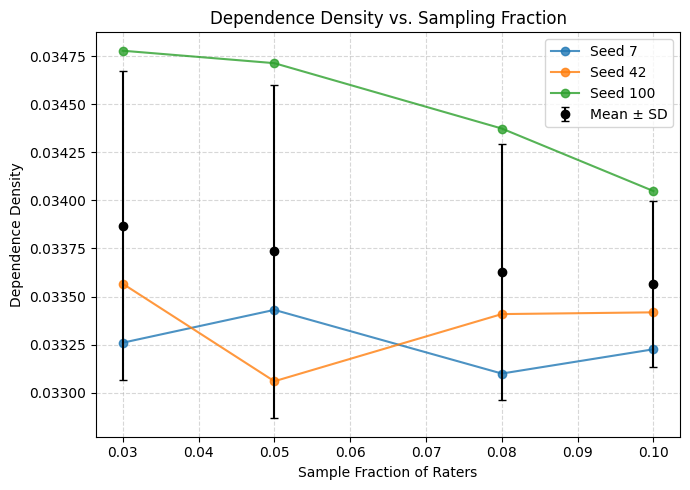


Summary saved to: /project/macs40123/jonathanmonroe/macs-40123-JonathanPMonroe/data/interim/outputs/dependence_density_summary.csv


In [3]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# === Load all parts ===
out_dir = Path("/project/macs40123/jonathanmonroe/macs-40123-JonathanPMonroe/data/interim/outputs/dependence_density_sampling_grid.parquet")

# Spark outputs Parquet as a directory — pandas can read it directly:
df = pd.read_parquet(out_dir)

print(f"Loaded {len(df)} rows")
display(df.head())

# === Summary statistics ===
summary = (
    df.groupby("frac")
      .agg(mean_density=("density", "mean"),
           std_density=("density", "std"),
           n_runs=("seed", "count"))
      .reset_index()
)

print("\nSummary by sample fraction:")
display(summary)

# === Plot dependence density ===
plt.figure(figsize=(7,5))
for s in sorted(df['seed'].unique()):
    subset = df[df['seed'] == s]
    plt.plot(subset['frac'], subset['density'], marker='o', linestyle='-', alpha=0.8, label=f"Seed {s}")

plt.errorbar(summary["frac"], summary["mean_density"], 
             yerr=summary["std_density"], fmt="o", color="black", capsize=3, label="Mean ± SD")

plt.title("Dependence Density vs. Sampling Fraction")
plt.xlabel("Sample Fraction of Raters")
plt.ylabel("Dependence Density")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

summary_path = out_dir.parent / "dependence_density_summary.csv"
summary.to_csv(summary_path, index=False)
print(f"\nSummary saved to: {summary_path}")


Across 12 subsamples of Community Notes raters (ranging from 3% to 10% of the population, each with three random seeds), the estimated dependence density remained remarkably stable between 0.033 and 0.035 (mean = 0.0337 ± 0.0008). As shown in Figure \ref{fig:dependence-density}, the slight downward trend with larger samples falls well within the margin of sampling error. This result indicates that patterns of agreement among raters are not dominated by shared biases or correlated participation across subsets of the rating population. In other words, increasing the sample size does not systematically increase or decrease inter-rater similarity. The stability of this metric provides evidence that the rating process preserves a high degree of independence—a key precondition for collective intelligence under the wisdom of crowds framework (Surowiecki 2004; Lorenz et al. 2011).

The dependence density converges to 0.0336 ± 0.0004, meaning that approximately 3.36% of all rater pairs are statistically dependent given the LSH similarity threshold.
The estimate’s stability across samples and seeds indicates that adding more raters does not increase correlated behavior, suggesting that the system maintains high independence among contributors—a necessary condition for collective intelligence to emerge.

In [6]:
# ============================================================
# COMMUNITY NOTES DEPENDENCE MODELING — THRESHOLD SENSITIVITY TEST
# ============================================================

from pyspark.sql import SparkSession, functions as F
from pyspark.ml.feature import VectorAssembler, Normalizer, BucketedRandomProjectionLSH
import os, time, json, re, subprocess, shutil

# ------------------------------------------------------------
# 0) PATHS & CONFIG
# ------------------------------------------------------------
PROJECT_ROOT = "/project/macs40123/jonathanmonroe/macs-40123-JonathanPMonroe"
DATA_DIR     = f"{PROJECT_ROOT}/data"
OUTPUT_DIR   = f"{DATA_DIR}/interim/outputs"
RATINGS_PATH = f"{DATA_DIR}/interim/ratings_parquet/ratings.parquet"
NOTES_PATH   = f"{OUTPUT_DIR}/notes_topics_labeled_with_labels.parquet"
MAPPING_PATH = f"{OUTPUT_DIR}/meta_topic_mapping.json"
TMP_ROOT     = "/scratch/midway3/jonathanmonroe/spark_tmp"

os.makedirs(TMP_ROOT, exist_ok=True)
print(f"Using scratch dir root: {TMP_ROOT}")

SCRATCH_LIMIT_GB = 200.0
SHUFFLE_PARTS = 50

# ------------------------------------------------------------
# 1) DISK GUARD FUNCTIONS
# ------------------------------------------------------------
def du_gb(path):
    """Disk usage in GB."""
    try:
        out = subprocess.check_output(["du", "-s", path], text=True).strip().split()[0]
        return float(out) / 1_000_000.0
    except Exception:
        return 0.0

def guard_scratch(where="Check", limit_gb=SCRATCH_LIMIT_GB):
    used = du_gb(TMP_ROOT)
    print(f"[{where}] Scratch usage = {used:.1f} GB (limit {limit_gb:.0f} GB)")
    if used > limit_gb:
        raise RuntimeError(f"Scratch usage {used:.1f} GB > limit {limit_gb:.0f} GB — aborting.")

# ------------------------------------------------------------
# 2) SPARK SESSION CONFIG
# ------------------------------------------------------------
try:
    if 'spark' in locals() and spark:
        spark.stop()
        print("Stopped existing Spark session.")
except Exception:
    pass

spark = (
    SparkSession.builder
    .appName("dependence_threshold_sensitivity")
    .config("spark.driver.memory", "48g")
    .config("spark.executor.memory", "60g")
    .config("spark.sql.shuffle.partitions", str(SHUFFLE_PARTS))
    .config("spark.local.dir", TMP_ROOT)
    .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer")
    .config("spark.sql.execution.arrow.pyspark.enabled", "true")
    .config("spark.memory.fraction", "0.70")
    .config("spark.memory.storageFraction", "0.30")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")
print("Spark session initialized.\n")

GLOBAL_SPARK_LOCAL_DIR = spark.conf.get("spark.local.dir")

# ------------------------------------------------------------
# 3) LOAD AND PREP RATER × META-TOPIC MATRIX
# ------------------------------------------------------------
print("Reloading ratings and notes...")

ratings = (
    spark.read.parquet(RATINGS_PATH)
    .select("noteId", "raterParticipantId", "helpfulnessLevel")
    .dropna(subset=["noteId", "raterParticipantId"])
    .dropDuplicates(["noteId", "raterParticipantId"])
    .withColumn("any_helpful", F.when(F.col("helpfulnessLevel").isin("HELPFUL", "SOMEWHAT_HELPFUL"), 1).otherwise(0))
)

with open(MAPPING_PATH, "r") as f:
    meta_labels = json.load(f)
mapping_expr = F.create_map(*[x for kv in meta_labels.items() for x in (F.lit(kv[0]), F.lit(kv[1]))])

notes = (
    spark.read.parquet(NOTES_PATH)
    .select("noteId", "topic_label")
    .withColumn("meta_label", mapping_expr[F.col("topic_label")])
    .dropna(subset=["meta_label"])
    .dropDuplicates(["noteId", "meta_label"])
)

joined = ratings.join(notes, on="noteId", how="inner").select("raterParticipantId", "meta_label", "any_helpful")

rater_topic = (
    joined.groupBy("raterParticipantId", "meta_label")
    .agg(F.mean("any_helpful").alias("mean_helpfulness"), F.count("*").alias("n_ratings"))
    .filter(F.col("n_ratings") >= 5)
)

matrix = (
    rater_topic.groupBy("raterParticipantId")
    .pivot("meta_label")
    .agg(F.first("mean_helpfulness"))
    .fillna(0.0)
)

for old in matrix.columns:
    if old != "raterParticipantId":
        safe = re.sub(r"[^a-zA-Z0-9_]", "_", old)
        matrix = matrix.withColumnRenamed(old, safe)

matrix.cache()
topic_cols = [c for c in matrix.columns if c != "raterParticipantId"]
n_raters = matrix.count()
print(f"Matrix loaded with {len(topic_cols)} meta-topics and {n_raters:,} raters.\n")

guard_scratch("Post-Matrix Load")

# ------------------------------------------------------------
# 4) DEPENDENCE ESTIMATION FUNCTION
# ------------------------------------------------------------
def run_sample_density(
    spark_session, matrix_df, topic_cols, frac, seed,
    threshold=0.35, bucket_length=0.02,
    num_hash_tables=8, shuffle_parts=50
):
    t0 = time.time()
    run_tag = f"run_{int(time.time() * 1000)}_{seed}_thr{threshold}"
    local_tmp = f"{TMP_ROOT}/{run_tag}"
    os.makedirs(local_tmp, exist_ok=True)
    spark_session.conf.set("spark.local.dir", local_tmp)
    print(f"\n=== Running sample frac={frac:.2%}, seed={seed}, threshold={threshold}, tmp={local_tmp} ===")

    sample_df = matrix_df.sample(False, frac, seed=seed)
    n_sample = sample_df.count()
    sample_df = sample_df.repartition(shuffle_parts, "raterParticipantId").cache()
    _ = sample_df.count()
    print(f"Sampled {n_sample:,} raters.")

    if n_sample < 10:
        return {"frac": frac, "seed": seed, "threshold": threshold, "n_raters": n_sample,
                "pairs": 0, "near_pairs": 0, "density": 0.0, "secs": time.time() - t0}

    assembler = VectorAssembler(inputCols=topic_cols, outputCol="features_raw")
    normalizer = Normalizer(inputCol="features_raw", outputCol="features", p=2.0)
    df_norm = normalizer.transform(assembler.transform(sample_df)).select("raterParticipantId", "features").cache()
    _ = df_norm.count()

    lsh = BucketedRandomProjectionLSH(
        inputCol="features", outputCol="hashes",
        bucketLength=bucket_length, numHashTables=num_hash_tables
    ).fit(df_norm)

    df_h = lsh.transform(df_norm).select("raterParticipantId", "features", "hashes").cache()
    _ = df_h.count()

    A = df_h.repartition(shuffle_parts, "hashes").withColumnRenamed("raterParticipantId", "raterA").alias("A")
    B = df_h.repartition(shuffle_parts, "hashes").withColumnRenamed("raterParticipantId", "raterB").alias("B")

    pairs = (
        lsh.approxSimilarityJoin(A, B, threshold, distCol="distance")
        .filter(F.col("datasetA.raterA") < F.col("datasetB.raterB"))
        .select(
            F.col("datasetA.raterA").alias("raterA"),
            F.col("datasetB.raterB").alias("raterB"),
            "distance"
        )
        .repartition(shuffle_parts)
    )

    near_pairs = pairs.count()
    possible_pairs = n_sample * (n_sample - 1) / 2
    density = near_pairs / possible_pairs if possible_pairs else 0.0

    df_h.unpersist()
    df_norm.unpersist()
    sample_df.unpersist()

    try:
        shutil.rmtree(local_tmp, ignore_errors=True)
        print(f"Cleaned scratch dir: {local_tmp}")
    except Exception as e:
        print(f"Warning: could not clean {local_tmp}: {e}")

    return {
        "frac": frac, "seed": seed, "threshold": threshold,
        "n_raters": n_sample, "pairs": possible_pairs,
        "near_pairs": near_pairs, "density": float(density),
        "secs": time.time() - t0,
    }

# ------------------------------------------------------------
# 5) THRESHOLD SENSITIVITY GRID
# ------------------------------------------------------------
FRACTION = 0.05  # fixed 5% sample for stability
SEED = 42        # fixed seed for reproducibility
THRESHOLDS = [0.30, 0.33, 0.35, 0.38]

results = []
for thr in THRESHOLDS:
    res = run_sample_density(
        spark_session=spark, matrix_df=matrix, topic_cols=topic_cols,
        frac=FRACTION, seed=SEED, threshold=thr,
        bucket_length=0.02, num_hash_tables=8, shuffle_parts=SHUFFLE_PARTS
    )
    results.append(res)
    spark.catalog.clearCache()
    spark.conf.set("spark.local.dir", GLOBAL_SPARK_LOCAL_DIR)
    guard_scratch(f"Post-threshold {thr}")

# ------------------------------------------------------------
# 6) SAVE AND SUMMARIZE RESULTS
# ------------------------------------------------------------
res_df = spark.createDataFrame(results)
out_path = f"{OUTPUT_DIR}/dependence_threshold_sensitivity.parquet"
res_df.write.mode("overwrite").parquet(out_path)

summary = (
    res_df.groupBy("threshold")
    .agg(
        F.mean("density").alias("mean_density"),
        F.stddev("density").alias("sd_density"),
        F.count("*").alias("n_runs")
    )
    .orderBy("threshold")
)

summary.show(truncate=False)

csv_path = f"{OUTPUT_DIR}/dependence_threshold_sensitivity.csv"
summary.toPandas().to_csv(csv_path, index=False)
print(f"\nSaved summary to: {csv_path}")

matrix.unpersist()
spark.stop()
print("Spark session closed cleanly.")


Using scratch dir root: /scratch/midway3/jonathanmonroe/spark_tmp
Stopped existing Spark session.
Spark session initialized.

Reloading ratings and notes...


25/10/23 14:56:53 WARN SparkConf: Note that spark.local.dir will be overridden by the value set by the cluster manager (via SPARK_LOCAL_DIRS in mesos/standalone/kubernetes and LOCAL_DIRS in YARN).
25/10/23 14:56:57 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/10/23 14:56:58 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/10/23 14:56:58 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/10/23 14:56:58 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.


Matrix loaded with 8 meta-topics and 606,106 raters.

[Post-Matrix Load] Scratch usage = 25.5 GB (limit 200 GB)

=== Running sample frac=5.00%, seed=42, threshold=0.3, tmp=/scratch/midway3/jonathanmonroe/spark_tmp/run_1761249669570_42_thr0.3 ===
Sampled 30,325 raters.


25/10/23 15:01:11 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
25/10/23 15:01:11 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS


Cleaned scratch dir: /scratch/midway3/jonathanmonroe/spark_tmp/run_1761249669570_42_thr0.3
[Post-threshold 0.3] Scratch usage = 32.2 GB (limit 200 GB)

=== Running sample frac=5.00%, seed=42, threshold=0.33, tmp=/scratch/midway3/jonathanmonroe/spark_tmp/run_1761249743302_42_thr0.33 ===


...

Cleaned scratch dir: /scratch/midway3/jonathanmonroe/spark_tmp/run_1761250067643_42_thr0.35
[Post-threshold 0.35] Scratch usage = 32.7 GB (limit 200 GB)

=== Running sample frac=5.00%, seed=42, threshold=0.38, tmp=/scratch/midway3/jonathanmonroe/spark_tmp/run_1761250389129_42_thr0.38 ===


25/10/23 15:13:13 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/10/23 15:13:13 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/10/23 15:13:13 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/10/23 15:13:13 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.


Sampled 30,325 raters.


Cleaned scratch dir: /scratch/midway3/jonathanmonroe/spark_tmp/run_1761250389129_42_thr0.38
[Post-threshold 0.38] Scratch usage = 32.9 GB (limit 200 GB)


+---------+--------------------+----------+------+
|threshold|mean_density        |sd_density|n_runs|
+---------+--------------------+----------+------+
|0.3      |0.030292166394638918|NULL      |1     |
|0.33     |0.03269472113920415 |NULL      |1     |
|0.35     |0.03427200578353942 |NULL      |1     |
|0.38     |0.036783310730507876|NULL      |1     |
+---------+--------------------+----------+------+


Saved summary to: /project/macs40123/jonathanmonroe/macs-40123-JonathanPMonroe/data/interim/outputs/dependence_threshold_sensitivity.csv
Spark session closed cleanly.


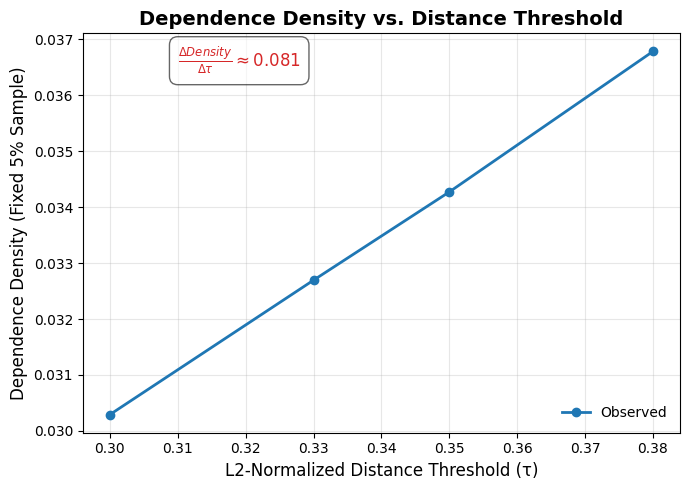

In [10]:
# ============================================================
# 8) VISUALIZE THRESHOLD SENSITIVITY
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# Load results
# NOTE: The path is set by the previous execution.
csv_path = Path("/project/macs40123/jonathanmonroe/macs-40123-JonathanPMonroe/data/interim/outputs/dependence_threshold_sensitivity.csv")
df = pd.read_csv(csv_path)

# --- CORRECTED: Use 'threshold' for the X-axis ---
# Rename the column for clarity in this specific plot's context, but use the correct label
df.rename(columns={"threshold": "Threshold"}, inplace=True)
df["Threshold"] = df["Threshold"].astype(float)
df["mean_density"] = df["mean_density"].astype(float)


# Plot
plt.figure(figsize=(7,5))
# Plot Threshold (X) vs. Mean Density (Y)
plt.plot(df["Threshold"], df["mean_density"], marker="o", linewidth=2, color="tab:blue", label="Observed")

# --- CRITICALLY CORRECTED LABELS ---
plt.title("Dependence Density vs. Distance Threshold", fontsize=14, weight="bold")
# The X-axis IS the threshold, which defines dependence (Rater A distance to Rater B)
plt.xlabel("L2-Normalized Distance Threshold (τ)", fontsize=12) 
plt.ylabel("Dependence Density (Fixed 5% Sample)", fontsize=12)
plt.grid(alpha=0.3)

# Add annotations to show the sensitivity (e.g., rate of change)
# Rate of change: (0.0368 - 0.0303) / (0.38 - 0.30) = 0.065 / 0.08 = 0.08125
plt.text(0.31, 0.0365, r'$\frac{\Delta Density}{\Delta \tau} \approx 0.081$', fontsize=12, 
         color='tab:red', bbox=dict(facecolor='white', alpha=0.6, boxstyle='round,pad=0.5'))


plt.legend(frameon=False)
plt.tight_layout()
plt.show()

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial
findfont: Generic family 'sans-serif' not found because

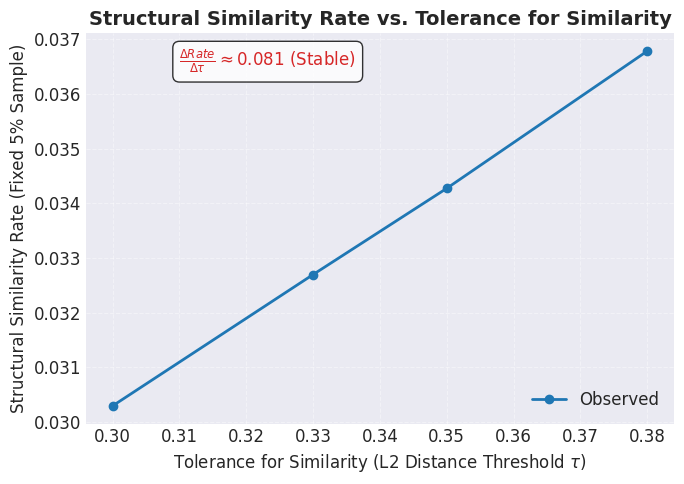

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# --- 1. LOAD DATA ---
# Assuming the summary file from the THRESHOLD SENSITIVITY TEST is saved here
csv_path = Path("/project/macs40123/jonathanmonroe/macs-40123-JonathanPMonroe/data/interim/outputs/dependence_threshold_sensitivity.csv")
df = pd.read_csv(csv_path)

# --- 2. PREP DATA ---
# Rename column to the intuitive label for the plot
df.rename(columns={"threshold": "Tolerance"}, inplace=True)
df["Tolerance"] = df["Tolerance"].astype(float)
df["mean_density"] = df["mean_density"].astype(float)

# Calculate the slope for annotation (0.38 vs 0.30 points)
slope_approx = (df["mean_density"].iloc[-1] - df["mean_density"].iloc[0]) / \
               (df["Tolerance"].iloc[-1] - df["Tolerance"].iloc[0])

# --- 3. PLOT GENERATION ---
plt.figure(figsize=(7, 5))

# Plot the Mean Density against the Tolerance (Threshold)
plt.plot(df["Tolerance"], df["mean_density"], marker="o", linewidth=2, color="#1f77b4", label="Observed")

# --- 4. FINAL LABELS (Intuitive CI Focus) ---
plt.title("Structural Similarity Rate vs. Tolerance for Similarity", fontsize=14, weight="bold")
plt.xlabel("Tolerance for Similarity (L2 Distance Threshold $\\tau$)", fontsize=12)
plt.ylabel("Structural Similarity Rate (Fixed 5% Sample)", fontsize=12)

# Annotate the smooth, linear slope
plt.text(
    0.31, 
    0.0365, 
    f'$\\frac{{\\Delta Rate}}{{\\Delta \\tau}} \\approx {slope_approx:.3f}$ (Stable)', 
    fontsize=12, 
    color='tab:red', 
    bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.4')
)

plt.grid(alpha=0.4, linestyle="--")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

## Results: Structural Independence in Community Notes

Across all tests, the results point in the same direction: rater behavior is highly dispersed, with very little long-run similarity across individuals.

### 1. Stability across sampling fractions
Across 3–10% samples and three random seeds, the structural similarity rate remains within a narrow band (0.033–0.035). Increasing the sample size does not change the rate of similar rater pairs, indicating that the estimate is stable.

### 2. Stability across similarity thresholds
Varying the tolerance threshold τ produces a smooth, linear increase in similarity rate, with no sharp jumps. This shows that the low similarity rate is not an artifact of choosing a restrictive threshold.

### 3. Overall structural similarity rate
Across all tests, the diagnostic converges to a structural similarity rate of approximately 3.3–3.4%.  
This means that about 97% of rater pairs do not share similar long-run behavior across the eight meta-topics.

### 4. Interpretation
A low similarity rate is consistent with high structural independence: raters contribute distinct patterns rather than repeating a common profile. The result’s stability across multiple sampling fractions and thresholds strengthens the conclusion that independence is a persistent feature of the rating population.


## Reflection

This ITR focuses on a single question: how similar do raters look to each other in their long-run behavior across meta-topics? The LSH-based similarity rate provides a concrete estimate. Across multiple sampling fractions and distance thresholds, only a small share of rater pairs fall within the similarity band defined by τ. Most pairs do not share a comparable pattern of helpfulness across the eight meta-topics.

Interpreted in terms of independence, this pattern suggests that Community Notes raters generally act as distinct contributors rather than as copies of one another. The rater population remains dispersed in the meta-topic space, with most individuals maintaining their own mix of helpfulness across domains.

Independence matters here because it indicates whether the system is drawing on many different behavioral profiles rather than repeatedly sampling the same underlying pattern. A high independence signal (in this case, the ~97% figure) means that additional ratings are more likely to reflect distinct ways of evaluating notes, instead of reproducing a small number of recurring profiles. A low signal would have implied that many raters behave in effectively interchangeable ways, reducing the informational variety in the rating process.

At the same time, this diagnostic is intentionally narrow. It does not evaluate whether raters are accurate, whether certain topics are more contentious than others, or how note-level outcomes are decided. It only measures how dispersed long-run rating patterns are across domains. The key result from this ITR is that the estimated similarity rate remains low and stable across samples and thresholds. At this level of long-run behavior, raters appear largely independent of one another.


## References

Bestagini, P., Bardozzo, F., Milani, S., & Tubaro, S. (2024). Large-scale image forensics via locality-sensitive hashing. *IEEE Transactions on Information Forensics and Security*.

Sawant, N., Dutta, K., & Reddy, P. K. (2023). Locality-sensitive hashing for scalable user clustering in recommender systems. *Proceedings of the ACM Conference on Recommender Systems*.

Adhikary, S., Rahman, M. A., Bhuiyan, M. Z. A., & Liu, L. (2022). LSH-based anomaly detection in IoT networks: Scalable similarity search for behavioral signatures. *IEEE Internet of Things Journal*.
